# Steady-vault data audit and A0b baseline

This notebook implements NB10 from steady-vault-plan-01.md. It audits manually identified StratWise-like examples and establishes the A0b baseline for later notebooks.

Examples are descriptive discovery cases, not an address whitelist or fitted labels: StratWise, PF1, Passivbot Canon, FuturAI Medium, FuturAI Low, and jump/plateau counterexamples Citadel, Satori Quantum and HYPErQuantum4. Metrics use gross share-price units and do not invent slippage, liquidation or execution assumptions.

The original A0b replay remains the control. The held-NAV ledger is a separate A0b-v2 data diagnostic: it checks whether held addresses still have causal NAV marks independently of feature eligibility. It does not create forced exits or claim a corrected execution backtest.

In [1]:
from pathlib import Path
import hashlib
import json
import math
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_DIR = Path.cwd() / "scratchpad/hyperliquid-ic" if (Path.cwd() / "scratchpad/hyperliquid-ic").exists() else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR))
REWRITE = PROJECT_DIR / "_artifacts-rewrite"
A0B = PROJECT_DIR / "_artifacts-a0b"
OUT = PROJECT_DIR / "_artifacts-steady-vault-data"
OUT.mkdir(exist_ok=True)

FEATURES = pd.read_parquet(REWRITE / "features.parquet")
FEATURES["date"] = pd.to_datetime(FEATURES.date).dt.normalize()
FEATURES["address"] = FEATURES.address.str.lower()
OBS = pd.read_parquet(REWRITE / "observations.parquet", columns=["address", "timestamp", "written_at", "share_price", "raw_share_price", "is_fresh", "hypercore_repair_status", "hypercore_source", "total_assets"])
OBS["address"] = OBS.address.str.lower()
OBS["timestamp"] = pd.to_datetime(OBS.timestamp)
RAW = pd.read_parquet(REWRITE / "raw-observations.parquet", columns=["address", "timestamp", "written_at", "share_price", "raw_share_price", "is_fresh", "hypercore_repair_status", "hypercore_source", "name"])
RAW["address"] = RAW.address.str.lower()
RAW["timestamp"] = pd.to_datetime(RAW.timestamp)
METADATA = pd.read_csv(REWRITE / "vault-metadata.csv")
METADATA["address"] = METADATA.address.str.lower()
ELIGIBILITY = pd.read_parquet(REWRITE / "eligibility.parquet")
ELIGIBILITY["date"] = pd.to_datetime(ELIGIBILITY.date).dt.normalize()
ELIGIBILITY["address"] = ELIGIBILITY.address.str.lower()

UNIVERSE_CACHE = Path("/Users/moo/.cache/indicators/vault-universe-tvl7500-top9999-age0.0-sort1Y-curbbf10d84.json")
universe_json = json.loads(UNIVERSE_CACHE.read_text())
universe_items = universe_json.get("vaults", universe_json) if isinstance(universe_json, dict) else universe_json
PRODUCTION_ALLOWLIST = {item["address"].lower() for item in universe_items if "address" in item}
MANUAL_BLACKLIST = {"0x5290ab34acb59cfe1371baa5782eba14433d308f"}
A0B_ALLOWLIST = PRODUCTION_ALLOWLIST - MANUAL_BLACKLIST
PERIODS = {"hyper_ai": (pd.Timestamp("2026-01-01"), pd.Timestamp("2026-07-08")), "full": (pd.Timestamp("2025-09-13"), pd.Timestamp("2026-09-12")), "recent": (pd.Timestamp("2026-07-16"), pd.Timestamp("2026-09-12"))}
STALE_MARK_DAYS = 7.0
EXAMPLES = {"StratWise": "0x0ff219ac20596b457558341bc410bc7a08a1394c", "PF1": "0xa1b6d8efbcb2fb750a84dbc05649fa4968034f04", "Passivbot Canon": "0x490af7d4a048a81db0f677517ed6373565b42349", "FuturAI Medium": "0x53375ca9a649f337d83d0834fec0db97640a2a06", "FuturAI Low": "0xb65dd7c56afbf3b272ab5fc49be44b47dca18003", "Citadel": "0xda51323fe9800c8365646ad5c7ade0dd17fdc167", "Satori Quantum": "0xbbf7d7a9d0eaeab4115f022a6863450296112422", "HYPErQuantum4": "0xc16e0bf84ea8c2b85457010602cb6fa030bc1fd4"}
LABELS = {"StratWise": "recent steady reference; young history", "PF1": "recent steady; older stress", "Passivbot Canon": "recent steady; older stress", "FuturAI Medium": "slow smooth; related family", "FuturAI Low": "slow smooth; related family", "Citadel": "jump dominated / plateau", "Satori Quantum": "jump dominated counterexample", "HYPErQuantum4": "consistent growth with higher risk"}
print({"features": FEATURES.shape, "observations": OBS.shape, "raw": RAW.shape, "allowlist": len(PRODUCTION_ALLOWLIST), "a0b_allowlist": len(A0B_ALLOWLIST)})


{'features': (104618, 410), 'observations': (487738, 9), 'raw': (1495861, 9), 'allowlist': 339, 'a0b_allowlist': 338}


## Source and universe provenance

The production-style allowlist is applied retrospectively because this is the agreed A0b reproduction universe. It is a conditional baseline, not a point-in-time survivor-free backtest. The frozen research data is reconstructed economic history; written_at is retained for audit but is not treated as economic observation time. share_price is the cleaned price used by the feature panel; raw prices and repair statuses are inspected separately.

In [2]:
def sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

source_paths = [REWRITE / "features.parquet", REWRITE / "observations.parquet", REWRITE / "raw-observations.parquet", REWRITE / "vault-metadata.csv", REWRITE / "eligibility.parquet", UNIVERSE_CACHE]
manifest = {"notebook": "10-research-steady-vault-data-and-a0b.ipynb", "periods": {k: [str(a.date()), str(b.date())] for k, (a, b) in PERIODS.items()}, "starting_cash": 150000, "production_allowlist_count": len(PRODUCTION_ALLOWLIST), "a0b_allowlist_count": len(A0B_ALLOWLIST), "manual_blacklist": sorted(MANUAL_BLACKLIST), "universe_contract": "A0 with frozen production-style allowlist minus manual blacklist", "survivorship_warning": "the current production-style allowlist is a retrospective conditional universe and is not survivor-free", "held_nav_cutoff": "calendar-date end at 23:59:59.999999 UTC; diagnostic only, not a decision-time feature", "held_position_check": "ledger checks held-address count against the independent A0b n_positions output; it does not prove per-address identity", "cleaned_older_than_raw_description": "true means the cleaning step rejected a newer raw observation for the carried cleaned mark", "stale_mark_threshold_days": STALE_MARK_DAYS, "source_files": {str(p): {"size": p.stat().st_size, "mtime": pd.Timestamp(p.stat().st_mtime, unit="s").isoformat(), "sha256": sha256(p)} for p in source_paths}}
(OUT / "input-manifest.json").write_text(json.dumps(manifest, indent=2, default=str))
display(pd.DataFrame([{"source": str(p), "size": p.stat().st_size, "sha256_prefix": manifest["source_files"][str(p)]["sha256"][:16]} for p in source_paths]))


,source,size,sha256_prefix
0,/Users/moo/code/getting-started/scratchpad/hyp...,85751647,1636f3c1cad0b8a3
1,/Users/moo/code/getting-started/scratchpad/hyp...,14943771,3e6aeb3aa274da49
2,/Users/moo/code/getting-started/scratchpad/hyp...,53603722,d81c76f693bb3668
3,/Users/moo/code/getting-started/scratchpad/hyp...,24755943,74bbfb74590e2200
4,/Users/moo/code/getting-started/scratchpad/hyp...,1538084,7ace5187f503e7d5
5,/Users/moo/.cache/indicators/vault-universe-tv...,30851,e4fadadb419d2310


## Example identity, panel coverage and A0b membership

Address is the authoritative identity. StratWise is mapped by its verified address because the frozen metadata has no matching name row.

In [3]:
metadata_by_address = METADATA.drop_duplicates("address").set_index("address")
feature_counts = FEATURES.groupby("address").size().rename("feature_rows")
obs_counts = OBS.groupby("address").agg(observation_rows=("timestamp", "size"), first_observation=("timestamp", "min"), last_observation=("timestamp", "max"))
identity_rows = []
for label, address in EXAMPLES.items():
    row = metadata_by_address.loc[address] if address in metadata_by_address.index else pd.Series(dtype=object)
    identity_rows.append({"label": label, "address": address, "manual_description": LABELS[label], "metadata_name": row.get("name", np.nan), "metadata_slug": row.get("vault_slug", np.nan), "metadata_identity_match": bool(address in metadata_by_address.index), "feature_rows": int(feature_counts.get(address, 0)), "observation_rows": int(obs_counts.loc[address, "observation_rows"]) if address in obs_counts.index else 0, "first_observation": obs_counts.loc[address, "first_observation"] if address in obs_counts.index else pd.NaT, "last_observation": obs_counts.loc[address, "last_observation"] if address in obs_counts.index else pd.NaT, "in_production_allowlist": address in PRODUCTION_ALLOWLIST, "in_A0b": address in A0B_ALLOWLIST, "manual_blacklist": address in MANUAL_BLACKLIST, **{f"metadata_{name}": row.get(name, np.nan) for name in ("fee_mode", "fee_internalised", "performance_fee", "perf_fee", "management_fee", "mgmt_fee", "deposit_fee", "withdraw_fee", "fee_label")}})
identity = pd.DataFrame(identity_rows)
identity.to_csv(OUT / "manual-example-identity.csv", index=False)
display(identity)


,label,address,manual_description,metadata_name,metadata_slug,metadata_identity_match,feature_rows,observation_rows,first_observation,last_observation,...,manual_blacklist,metadata_fee_mode,metadata_fee_internalised,metadata_performance_fee,metadata_perf_fee,metadata_management_fee,metadata_mgmt_fee,metadata_deposit_fee,metadata_withdraw_fee,metadata_fee_label
0,StratWise,0x0ff219ac20596b457558341bc410bc7a08a1394c,recent steady reference; young history,NaN,NaN,False,58,355,2026-07-16 15:00:00.016,2026-09-13 13:35:53.085,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PF1,0xa1b6d8efbcb2fb750a84dbc05649fa4968034f04,recent steady; older stress,PF1,pf1,True,445,1145,2025-06-18 00:00:00.000,2026-09-13 13:35:25.073,...,False,internalised_skimming,True,0.1,0.1,0.0,0.0,0.0,0.0,0% / 10% (int.)
2,Passivbot Canon,0x490af7d4a048a81db0f677517ed6373565b42349,recent steady; older stress,Passivbot Canon,passivbot-canon,True,298,1121,2025-09-03 00:00:00.000,2026-09-13 13:38:39.037,...,False,internalised_skimming,True,0.1,0.1,0.0,0.0,0.0,0.0,0% / 10% (int.)
3,FuturAI Medium,0x53375ca9a649f337d83d0834fec0db97640a2a06,slow smooth; related family,"FuturAI Labs - High Sharpe, Medium Volatility",futurai-labs-high-sharpe-medium-volatility,True,161,974,2026-04-03 00:00:00.000,2026-09-13 13:38:44.104,...,False,internalised_skimming,True,0.1,0.1,0.0,0.0,0.0,0.0,0% / 10% (int.)
4,FuturAI Low,0xb65dd7c56afbf3b272ab5fc49be44b47dca18003,slow smooth; related family,"FuturAI Labs - High Sharpe, Low Volatility",futurai-labs-high-sharpe-low-volatility,True,194,1038,2026-02-26 00:00:00.000,2026-09-13 13:36:31.072,...,False,internalised_skimming,True,0.1,0.1,0.0,0.0,0.0,0.0,0% / 10% (int.)
5,Citadel,0xda51323fe9800c8365646ad5c7ade0dd17fdc167,jump dominated / plateau,Citadel,citadel,True,545,1194,2023-11-22 00:00:00.000,2026-09-13 13:34:23.094,...,False,internalised_skimming,True,0.1,0.1,0.0,0.0,0.0,0.0,0% / 10% (int.)
6,Satori Quantum,0xbbf7d7a9d0eaeab4115f022a6863450296112422,jump dominated counterexample,Satori Quantum HF Vault,satori-quantum-hf-vault,True,545,1171,2025-03-05 00:00:00.000,2026-09-13 13:34:54.058,...,False,internalised_skimming,True,0.1,0.1,0.0,0.0,0.0,0.0,0% / 10% (int.)
7,HYPErQuantum4,0xc16e0bf84ea8c2b85457010602cb6fa030bc1fd4,consistent growth with higher risk,HYPErQuantum4,hyperquantum4,True,309,1120,2025-08-20 00:00:00.000,2026-09-13 13:38:34.069,...,False,internalised_skimming,True,0.1,0.1,0.0,0.0,0.0,0.0,0% / 10% (int.)


## Curve metrics

Metrics use observed daily endpoints where available; missing calendar days are not filled with zero returns. Volatility uses consecutive one-day intervals. Event concentration uses all observed positive intervals and is cadence-sensitive. Annualised short-window growth describes observed pace; it is not a forecast.

In [4]:
def daily_curve(address, start=None, end=None, price_column="share_price"):
    frame = OBS[OBS.address == address].sort_values("timestamp")
    if start is not None:
        frame = frame[frame.timestamp >= start]
    if end is not None:
        frame = frame[frame.timestamp < end + pd.Timedelta(days=1)]
    if frame.empty:
        return pd.Series(dtype=float)
    series = frame.set_index("timestamp")[price_column].resample("1D").last().dropna()
    return series[series.gt(0)]

def curve_metrics(address, start=None, end=None):
    series = daily_curve(address, start, end)
    if len(series) < 2:
        return {"observed_marks": len(series), "span_days": np.nan}
    intervals = series.index.to_series().diff().dt.total_seconds().div(86400)
    log_returns = np.log(series / series.shift(1)).dropna()
    valid_intervals = intervals.loc[log_returns.index]
    elapsed_days = max((series.index[-1] - series.index[0]).total_seconds() / 86400, 1)
    gains = log_returns[log_returns.gt(0)]
    daily = log_returns[valid_intervals.between(0.999, 1.001)]
    weekly = []
    anchor_timestamp, anchor_value = series.index[0], float(series.iloc[0])
    for timestamp, value in series.iloc[1:].items():
        distance = (timestamp - anchor_timestamp).total_seconds() / 86400
        if distance > 10:
            # Reset after a long gap; a multi-week jump is not a weekly result.
            anchor_timestamp, anchor_value = timestamp, float(value)
        elif distance >= 5:
            weekly.append(float(value) / anchor_value - 1)
            anchor_timestamp, anchor_value = timestamp, float(value)
    drawdown = series / series.cummax() - 1
    total_log = float(np.log(series.iloc[-1] / series.iloc[0]))
    best_event = float(gains.max()) if len(gains) else 0.0
    half = series.index[0] + (series.index[-1] - series.index[0]) / 2
    first, second = series[series.index <= half], series[series.index > half]
    return {"observed_marks": int(len(series)), "span_days": float(elapsed_days), "first_mark": series.index[0], "last_mark": series.index[-1], "cumulative_return": float(series.iloc[-1] / series.iloc[0] - 1), "annualised_growth": float(np.expm1(total_log * 365 / elapsed_days)), "first_half_return": float(first.iloc[-1] / first.iloc[0] - 1) if len(first) >= 2 else np.nan, "second_half_return": float(second.iloc[-1] / second.iloc[0] - 1) if len(second) >= 2 else np.nan, "annualised_one_day_vol": float(daily.std(ddof=1) * math.sqrt(365)) if len(daily) >= 2 else np.nan, "annualised_downside": float(np.sqrt(np.square(daily[daily < 0]).sum() / (elapsed_days / 365))) if len(daily) else np.nan, "max_drawdown": float(drawdown.min()), "best_event_removed_growth": float(np.expm1((total_log - best_event) * 365 / elapsed_days)), "best_positive_event_share": float(best_event / gains.sum()) if len(gains) and gains.sum() > 0 else np.nan, "top3_positive_event_share": float(gains.nlargest(3).sum() / gains.sum()) if len(gains) and gains.sum() > 0 else np.nan, "positive_observed_week_share": float(np.mean(np.asarray(weekly) > 0)) if weekly else np.nan, "weekly_outcomes": int(len(weekly)), "max_gap_days": float(valid_intervals.max()) if len(valid_intervals) else np.nan, "zero_return_share": float(np.mean(log_returns.eq(0))) if len(log_returns) else np.nan}

metric_rows = []
for label, address in EXAMPLES.items():
    for period_name, (start, end) in PERIODS.items():
        if period_name == "hyper_ai":
            continue
        row = {"label": label, "address": address, "period": period_name, "manual_description": LABELS[label]}
        row.update(curve_metrics(address, start, end))
        metric_rows.append(row)
metrics = pd.DataFrame(metric_rows)
metrics.to_csv(OUT / "manual-example-metrics.csv", index=False)
display(metrics[["label", "period", "observed_marks", "span_days", "cumulative_return", "annualised_growth", "annualised_one_day_vol", "annualised_downside", "max_drawdown", "best_event_removed_growth", "best_positive_event_share", "top3_positive_event_share", "positive_observed_week_share", "max_gap_days"]].round(4))


,label,period,observed_marks,span_days,cumulative_return,annualised_growth,annualised_one_day_vol,annualised_downside,max_drawdown,best_event_removed_growth,best_positive_event_share,top3_positive_event_share,positive_observed_week_share,max_gap_days
0,StratWise,full,59,58.0,0.0404,0.2834,0.0390,0.0185,-0.0065,0.2209,0.1411,0.3635,0.8182,1.0
1,StratWise,recent,59,58.0,0.0404,0.2834,0.0390,0.0185,-0.0065,0.2209,0.1411,0.3635,0.8182,1.0
2,PF1,full,254,360.0,0.3833,0.3895,0.2026,0.1173,-0.1352,0.3095,0.0692,0.1872,0.7538,7.0
3,PF1,recent,59,58.0,0.0493,0.3540,0.0352,0.0173,-0.0058,0.3064,0.0853,0.2380,1.0000,1.0
4,Passivbot Canon,full,255,360.0,0.2390,0.2427,0.2273,0.1235,-0.1385,0.1386,0.1042,0.2188,0.6615,7.0
5,Passivbot Canon,recent,59,58.0,0.0395,0.2763,0.0394,0.0195,-0.0089,0.1926,0.1976,0.3376,0.8182,1.0
6,FuturAI Medium,full,163,162.0,0.0559,0.1304,0.1036,0.0835,-0.0602,0.0447,0.2360,0.3677,0.8750,1.0
7,FuturAI Medium,recent,59,58.0,0.0171,0.1128,0.0118,0.0033,-0.0012,0.0919,0.1483,0.3271,1.0000,1.0
8,FuturAI Low,full,199,198.0,0.0539,0.1015,0.0561,0.0345,-0.0336,0.0470,0.2176,0.3472,0.8205,1.0
9,FuturAI Low,recent,59,58.0,0.0156,0.1021,0.0135,0.0051,-0.0014,0.0798,0.1612,0.3638,1.0000,1.0


## Standardised and absolute history charts

Standardised charts make path shape comparable from each first observed mark. Absolute charts preserve share-price scale and expose precision, jumps and plateaus.

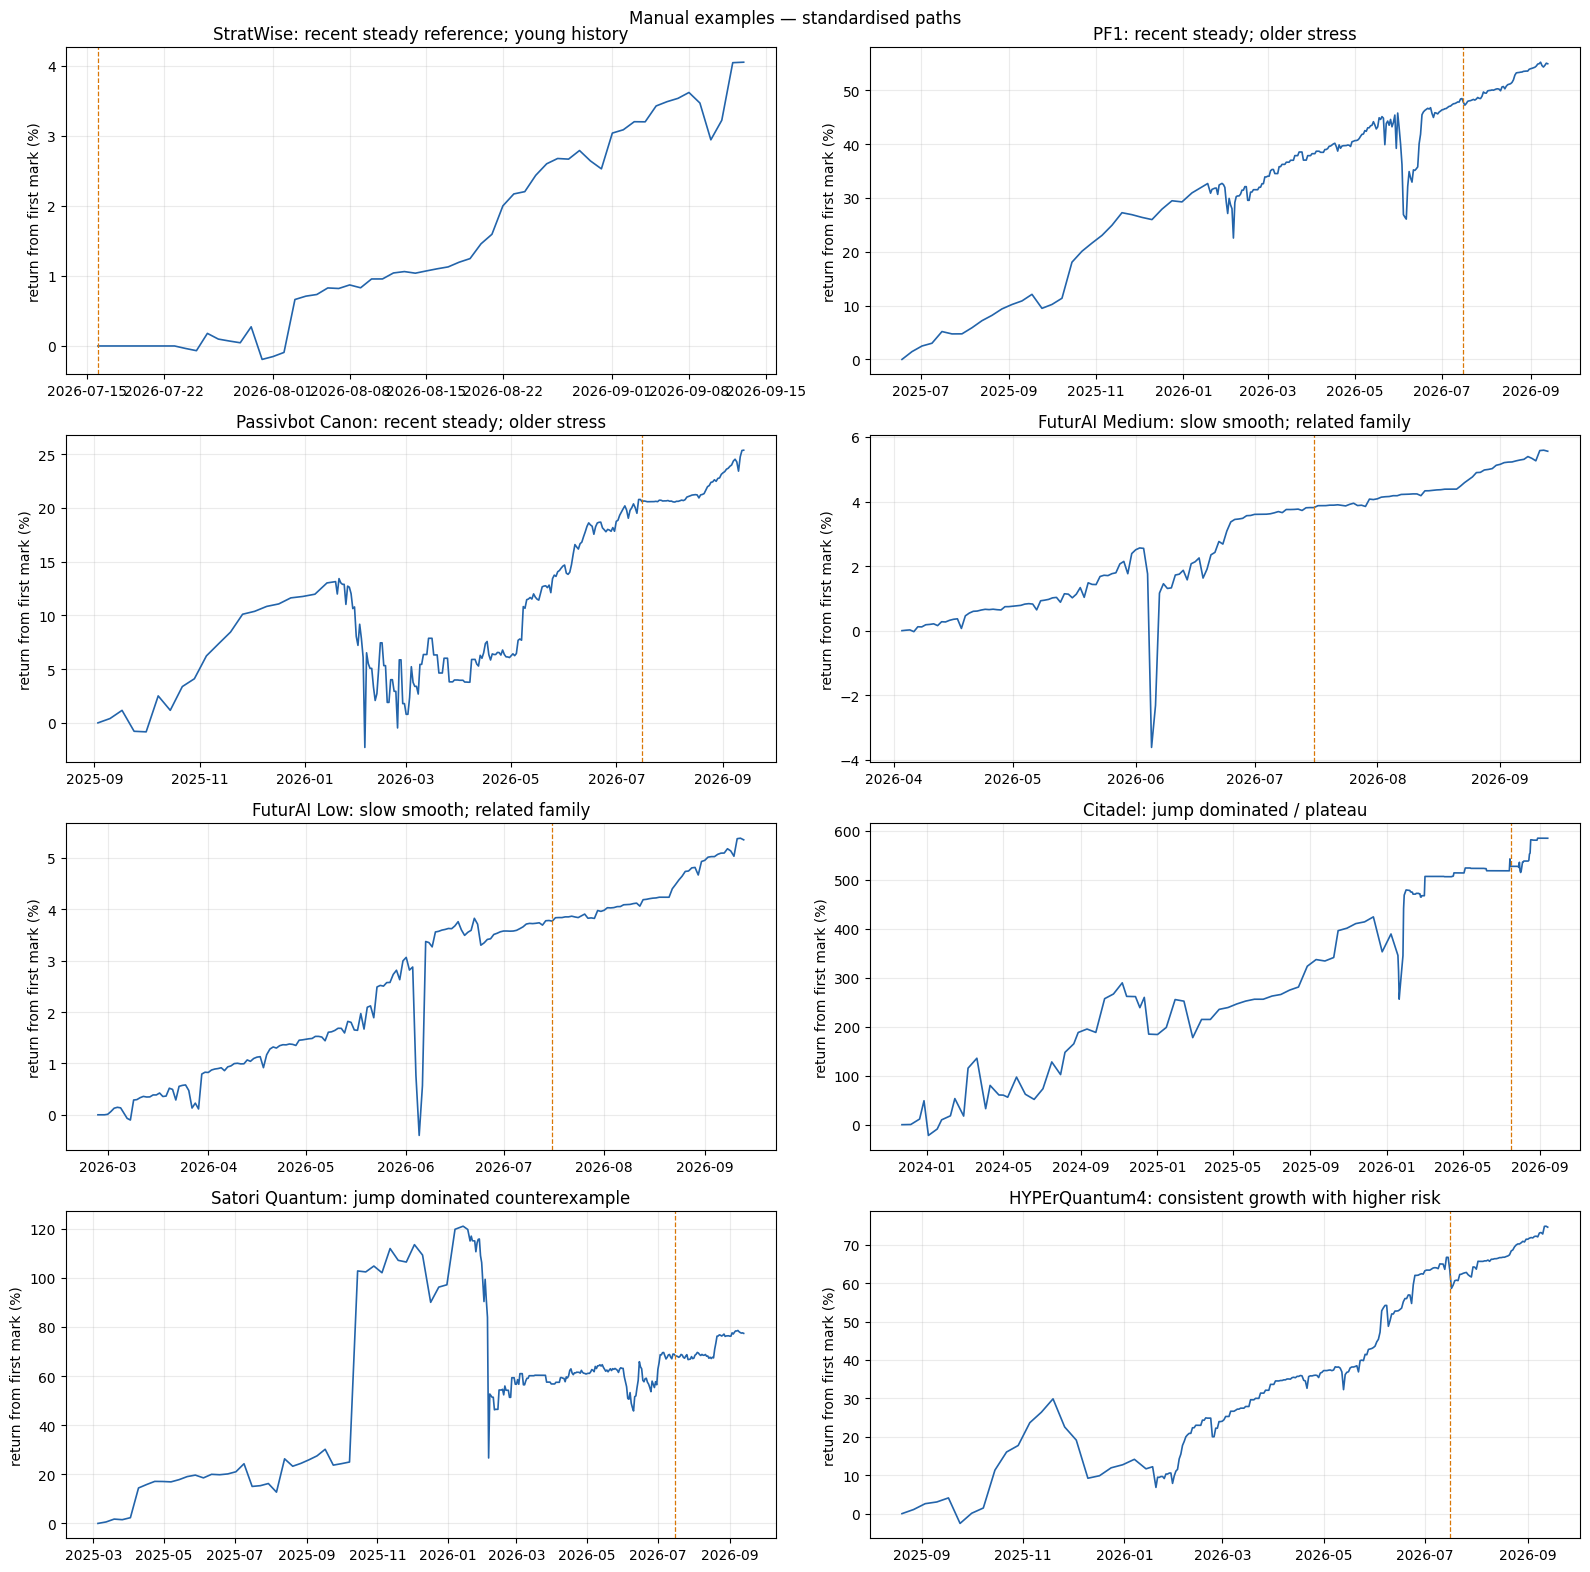

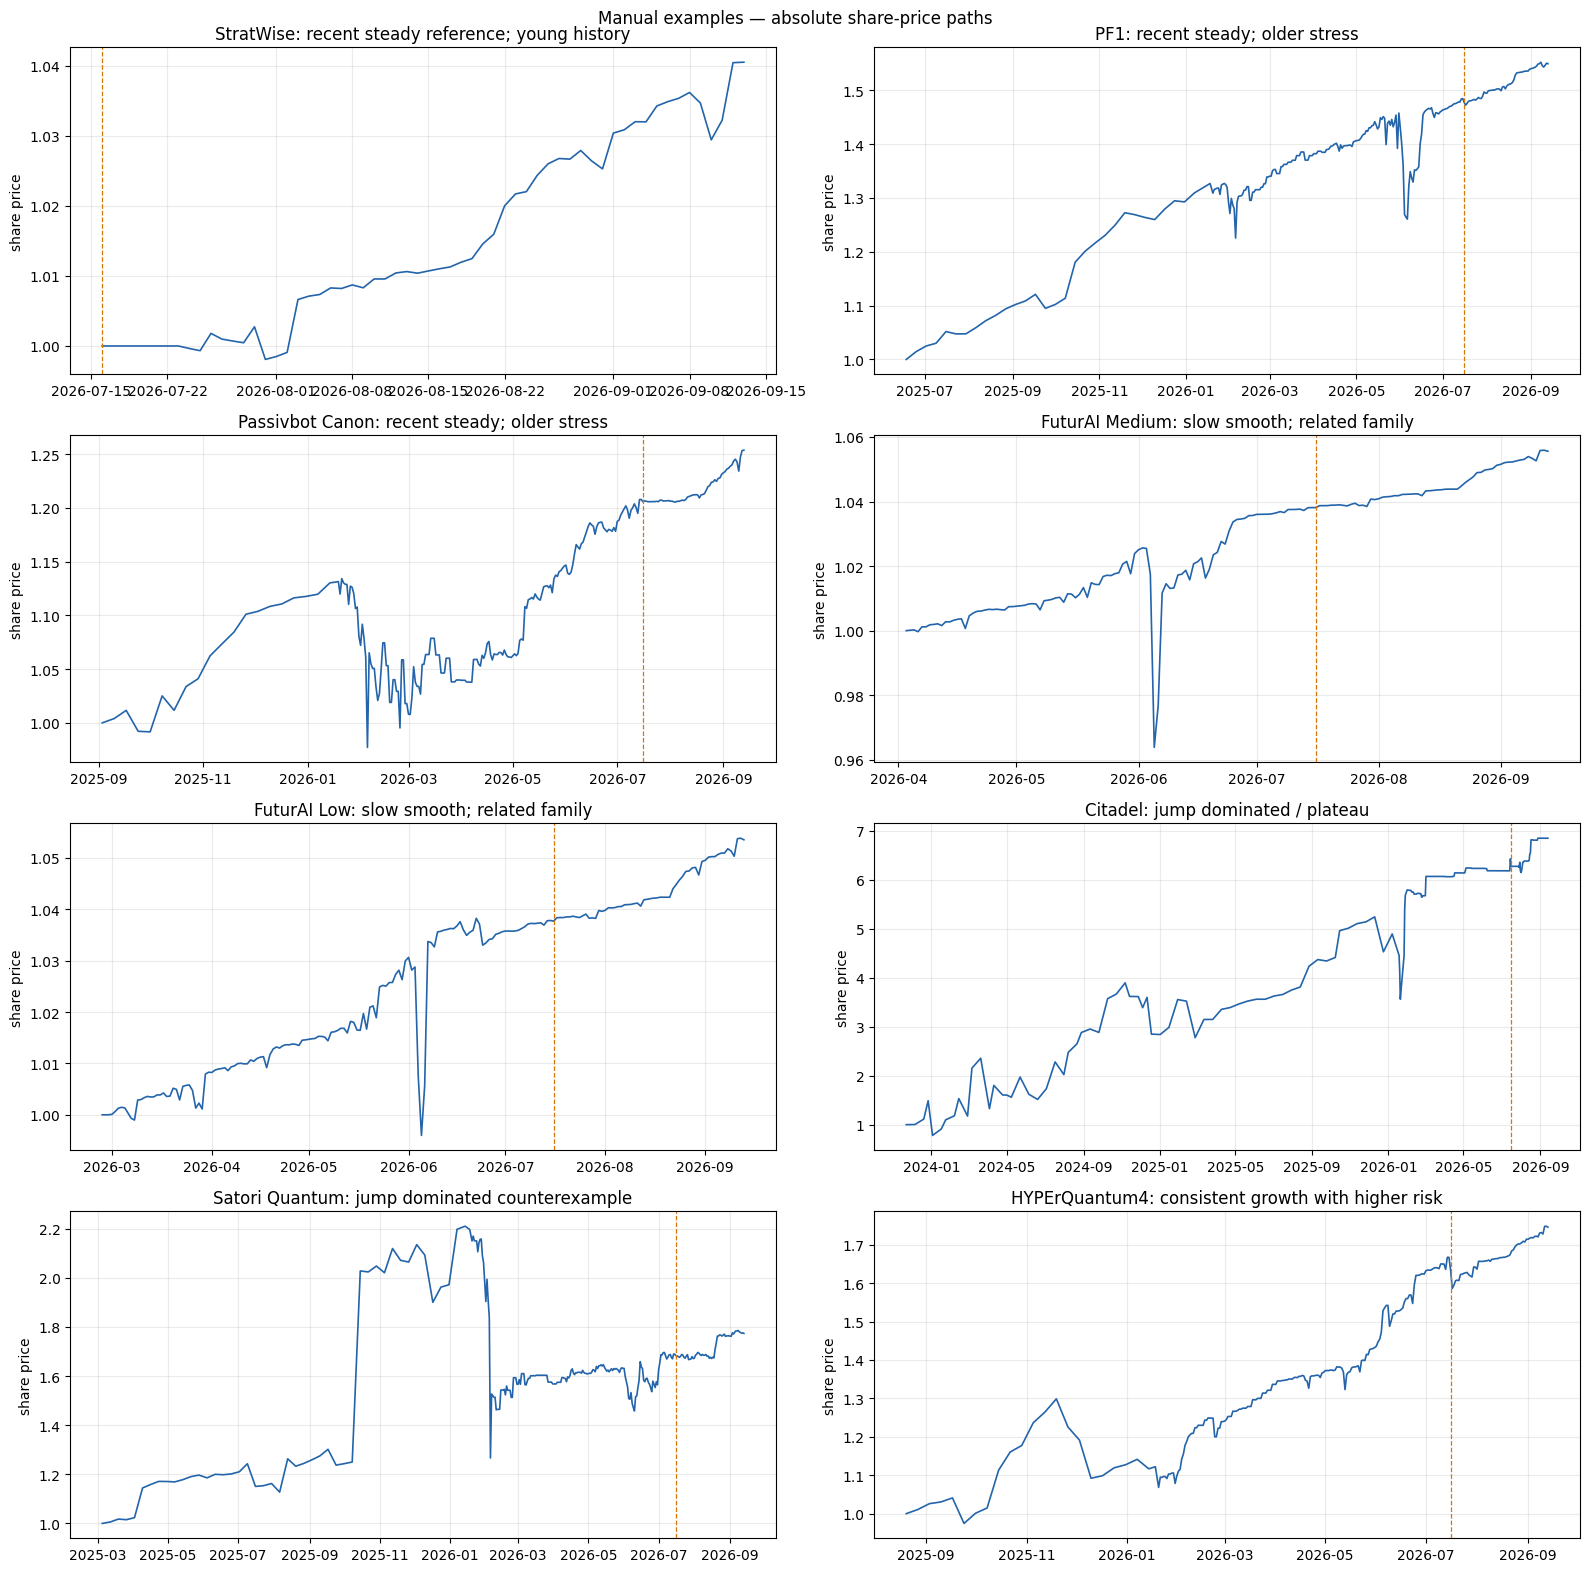

In [5]:
for standardised in (True, False):
    fig, axes = plt.subplots(4, 2, figsize=(16, 16))
    for axis, label in zip(axes.flat, EXAMPLES):
        series = daily_curve(EXAMPLES[label])
        values = 100 * (series / series.iloc[0] - 1) if standardised else series
        axis.plot(values.index, values.values, color="#2364aa", linewidth=1.2)
        axis.axvline(PERIODS["recent"][0], color="#d97706", linestyle="--", linewidth=0.9)
        axis.set_title(f"{label}: {LABELS[label]}")
        axis.set_ylabel("return from first mark (%)" if standardised else "share price")
        axis.grid(alpha=0.25)
    for axis in axes.flat[len(EXAMPLES):]:
        axis.axis("off")
    fig.suptitle("Manual examples — " + ("standardised paths" if standardised else "absolute share-price paths"))
    fig.tight_layout()
    filename = OUT / ("example-curves-standardised.png" if standardised else "example-curves-absolute.png")
    fig.savefig(filename, dpi=130)
    plt.show()


## Raw, repaired and publication provenance audit

For each example, report raw-versus-cleaned price differences, base versus exceptional status counts, source/status values, and the worst observed daily event under raw and cleaned marks. A cleaned drop is not called a trading loss when raw input or repair metadata does not support that interpretation.

In [6]:
def raw_audit(address):
    frame = RAW[RAW.address == address].sort_values("timestamp").copy()
    if frame.empty:
        return {"raw_rows": 0}
    frame["repair_difference"] = (pd.to_numeric(frame.share_price, errors="coerce") - pd.to_numeric(frame.raw_share_price, errors="coerce")).abs()
    status = frame.hypercore_repair_status.astype("string").fillna("").str.strip()
    base_statuses = {"approximated_pnl_nav", "approximated_pnl_nav_carried"}
    price_changed = frame.repair_difference.gt(1e-12)
    non_base_status = status.ne("") & ~status.isin(base_statuses)
    repaired = price_changed | non_base_status
    def worst(column):
        series = frame.set_index("timestamp")[column].resample("1D").last().dropna()
        returns = np.log(series / series.shift(1)).dropna()
        return (float(returns.min()), returns.idxmin()) if len(returns) else (np.nan, pd.NaT)
    raw_drop, raw_date = worst("raw_share_price")
    clean_drop, clean_date = worst("share_price")
    status_counts = status[status.ne("")].value_counts()
    return {"raw_rows": int(len(frame)), "raw_first": frame.timestamp.min(), "raw_last": frame.timestamp.max(), "price_changed_rows": int(price_changed.sum()), "price_changed_fraction": float(price_changed.mean()), "non_base_status_rows": int(non_base_status.sum()), "non_base_status_fraction": float(non_base_status.mean()), "repair_or_status_rows": int(repaired.sum()), "repair_or_status_fraction": float(repaired.mean()), "distinct_sources": ",".join(sorted(frame.hypercore_source.dropna().astype(str).unique())), "distinct_repair_statuses": ",".join(sorted(status[status.ne("")].unique())), "status_counts": json.dumps({str(key): int(value) for key, value in status_counts.items()}, sort_keys=True), "max_price_difference": float(frame.repair_difference.max()), "raw_worst_daily_log_return": raw_drop, "raw_worst_date": raw_date, "clean_worst_daily_log_return": clean_drop, "clean_worst_date": clean_date}

repair_audit = pd.DataFrame([{"label": label, "address": address, **raw_audit(address)} for label, address in EXAMPLES.items()])
repair_audit.to_csv(OUT / "manual-example-repair-audit.csv", index=False)
display(repair_audit.round(6))


,label,address,raw_rows,raw_first,raw_last,price_changed_rows,price_changed_fraction,non_base_status_rows,non_base_status_fraction,repair_or_status_rows,repair_or_status_fraction,distinct_sources,distinct_repair_statuses,status_counts,max_price_difference,raw_worst_daily_log_return,raw_worst_date,clean_worst_daily_log_return,clean_worst_date
0,StratWise,0x0ff219ac20596b457558341bc410bc7a08a1394c,1017,2026-07-16 15:00:00.016,2026-09-13 13:35:53.085,919,0.903638,0,0.000000,919,0.903638,hf,"approximated_pnl_nav,approximated_pnl_nav_carried","{""approximated_pnl_nav"": 355, ""approximated_pn...",0.009302,-0.005343,2026-09-10,-0.005088,2026-09-10
1,PF1,0xa1b6d8efbcb2fb750a84dbc05649fa4968034f04,2859,2025-06-18 00:00:00.000,2026-09-13 13:35:25.073,2858,0.999650,0,0.000000,2858,0.999650,"daily,hf","approximated_pnl_nav,approximated_pnl_nav_carried","{""approximated_pnl_nav"": 1145, ""approximated_p...",0.172097,-0.144613,2026-02-05,-0.070639,2026-06-04
2,Passivbot Canon,0x490af7d4a048a81db0f677517ed6373565b42349,2824,2025-09-03 00:00:00.000,2026-09-13 13:38:39.037,2823,0.999646,2,0.000708,2823,0.999646,"daily,hf","approximated_pnl_nav,approximated_pnl_nav_carr...","{""approximated_pnl_nav"": 1119, ""approximated_p...",0.141781,-0.242632,2026-02-05,-0.082283,2026-02-05
3,FuturAI Medium,0x53375ca9a649f337d83d0834fec0db97640a2a06,2663,2026-04-03 00:00:00.000,2026-09-13 13:38:44.104,2658,0.998122,5,0.001878,2658,0.998122,"daily,hf","approximated_pnl_nav,approximated_pnl_nav_carr...","{""approximated_pnl_nav"": 969, ""approximated_pn...",0.037709,-0.054453,2026-06-05,-0.054256,2026-06-05
4,FuturAI Low,0xb65dd7c56afbf3b272ab5fc49be44b47dca18003,3347,2026-02-26 00:00:00.000,2026-09-13 13:36:31.072,3344,0.999104,3,0.000896,3344,0.999104,"daily,hf","approximated_pnl_nav,approximated_pnl_nav_carr...","{""approximated_pnl_nav"": 1035, ""approximated_p...",0.026621,-0.020526,2026-06-04,-0.020773,2026-06-04
5,Citadel,0xda51323fe9800c8365646ad5c7ade0dd17fdc167,3333,2023-11-22 00:00:00.000,2026-09-13 13:34:23.094,3332,0.999700,0,0.000000,3332,0.999700,"daily,hf","approximated_pnl_nav,approximated_pnl_nav_carried","{""approximated_pnl_nav"": 1194, ""approximated_p...",57.318430,-0.645567,2024-01-03,-0.645567,2024-01-03
6,Satori Quantum,0xbbf7d7a9d0eaeab4115f022a6863450296112422,3067,2025-03-05 00:00:00.000,2026-09-13 13:34:54.058,3066,0.999674,0,0.000000,3066,0.999674,"daily,hf","approximated_pnl_nav,approximated_pnl_nav_carried","{""approximated_pnl_nav"": 1171, ""approximated_p...",1.650562,-0.878569,2026-02-05,-0.372884,2026-02-05
7,HYPErQuantum4,0xc16e0bf84ea8c2b85457010602cb6fa030bc1fd4,2812,2025-08-20 00:00:00.000,2026-09-13 13:38:34.069,2811,0.999644,3,0.001067,2811,0.999644,"daily,hf","approximated_pnl_nav,approximated_pnl_nav_carr...","{""approximated_pnl_nav"": 1117, ""approximated_p...",0.307396,-0.097907,2025-12-10,-0.086989,2025-12-10


## Original A0b parity and held-NAV / eligibility separation

The parity control reruns the existing independent A0b simulator on the exact saved periods and compares daily equity with the stored A0b curve. The separate held-NAV ledger reconstructs carried stale holdings from the pool and current feature rows, then uses the latest cleaned and raw observations available by an end-of-day causal cutoff. It reports whether a holding has a mark even when it has no eligible feature row, without forcing a sale or changing the control curve. Cleaned marks are the carried valuation diagnostic; raw marks define the dark-row diagnostic and repair provenance.

In [7]:
from ic_research import ResearchConfig
from stable_profit import simulate_stable_policy

CONFIG = ResearchConfig()
parity_rows = []
for period_name in ("hyper_ai", "full"):
    start, end = PERIODS[period_name]
    period_features = FEATURES[FEATURES.date.between(start, end)].copy()
    selected = set(period_features.address) & A0B_ALLOWLIST
    period_features = period_features[period_features.address.isin(selected)].copy()
    period_observations = OBS[OBS.timestamp.dt.normalize().between(start, end) & OBS.address.isin(selected) & OBS.is_fresh].copy()
    replay, _, _ = simulate_stable_policy(period_features, period_observations, policy_name="A0b", config=CONFIG, max_positions=6)
    stored_name = "production_candidate_period" if period_name == "hyper_ai" else "full_backfilled_history"
    stored = pd.read_parquet(A0B / f"equity-A0b-{stored_name}.parquet")
    replay["date"] = pd.to_datetime(replay.date).dt.normalize()
    stored["date"] = pd.to_datetime(stored.date).dt.normalize()
    joined = stored.merge(replay, on="date", suffixes=("_stored", "_replay"))
    diff = (joined.equity_stored - joined.equity_replay).abs()
    parity_rows.append({"period": period_name, "stored_rows": len(stored), "replay_rows": len(replay), "joined_rows": len(joined), "max_abs_equity_difference": float(diff.max()) if len(diff) else np.nan, "max_abs_cash_difference": float((joined.cash_stored - joined.cash_replay).abs().max()) if len(joined) else np.nan, "parity_pass": bool(len(stored) == len(replay) == len(joined) and diff.max() < 1e-6)})
    replay.to_parquet(OUT / f"a0b-replay-{period_name}.parquet", index=False)
parity = pd.DataFrame(parity_rows)
parity.to_csv(OUT / "a0b-parity-report.csv", index=False)
display(parity)


,period,stored_rows,replay_rows,joined_rows,max_abs_equity_difference,max_abs_cash_difference,parity_pass
0,hyper_ai,189,189,189,0.0,0.0,True
1,full,365,365,365,0.0,0.0,True


In [8]:
def held_nav_ledger(period_name):
    period_key = "production_candidate_period" if period_name == "hyper_ai" else "full_backfilled_history"
    equity = pd.read_parquet(A0B / f"equity-A0b-{period_key}.parquet")
    pool = pd.read_parquet(A0B / f"pool-A0b-{period_key}.parquet")
    equity["date"] = pd.to_datetime(equity.date).dt.normalize()
    pool["date"] = pd.to_datetime(pool.date).dt.normalize()
    pool_by_date = {date: g.set_index("address").target_dollars for date, g in pool.groupby("date")}
    feature_addresses_by_date = FEATURES.groupby("date").address.apply(set).to_dict()
    held = set()
    holding_rows = []
    for date in equity.date:
        if date in pool_by_date:
            day_pool = pool_by_date[date]
            positive = set(day_pool[day_pool.gt(0)].index)
            feature_addresses = feature_addresses_by_date.get(date, set())
            # Pool rows omit holdings carried solely through stale marks.  Carry
            # those addresses forward; a feature row with no positive target is
            # evidence that the simulator sold it at this rebalance.
            held = {address for address in held if address not in feature_addresses or address in positive}
            held |= positive
        cutoff = date + pd.Timedelta(days=1) - pd.Timedelta(microseconds=1)
        holding_rows.extend({"period": period_name, "date": date, "address": address, "cutoff": cutoff} for address in sorted(held))
    held_frame = pd.DataFrame(holding_rows)
    if held_frame.empty:
        return pd.DataFrame(columns=["period", "date", "address", "mark_cutoff", "has_causal_mark", "mark", "mark_timestamp", "mark_age_days", "mark_stale", "source", "repair_status", "raw_has_causal_mark", "raw_mark", "raw_mark_timestamp", "raw_mark_age_days", "raw_mark_stale", "cleaned_older_than_raw", "raw_source", "raw_repair_status", "feature_row_present", "eligible", "held_but_not_eligible", "dark_holding", "equity_n_positions", "ledger_n_positions", "position_count_mismatch"])
    # One merge_asof replaces a repeated full-observation scan for every holding/date.
    mark_frame = OBS[["address", "timestamp", "share_price", "hypercore_source", "hypercore_repair_status"]].copy()
    mark_frame["timestamp"] = pd.to_datetime(mark_frame["timestamp"]).astype("datetime64[ns]")
    held_frame["cutoff"] = pd.to_datetime(held_frame["cutoff"]).astype("datetime64[ns]")
    assert not mark_frame.duplicated(["address", "timestamp"]).any(), "clean observation merge keys must be unique"
    mark_frame = mark_frame.sort_values(["timestamp", "address"])
    held_frame = held_frame.sort_values(["cutoff", "address"])
    held_frame = pd.merge_asof(held_frame, mark_frame, left_on="cutoff", right_on="timestamp", by="address", direction="backward", allow_exact_matches=True)
    raw_mark_frame = RAW[["address", "timestamp", "raw_share_price", "hypercore_source", "hypercore_repair_status"]].copy()
    raw_mark_frame = raw_mark_frame.rename(columns={"timestamp": "raw_timestamp", "hypercore_source": "raw_hypercore_source", "hypercore_repair_status": "raw_hypercore_repair_status"})
    raw_mark_frame["raw_timestamp"] = pd.to_datetime(raw_mark_frame["raw_timestamp"]).astype("datetime64[ns]")
    assert not raw_mark_frame.duplicated(["address", "raw_timestamp"]).any(), "raw observation merge keys must be unique"
    raw_mark_frame = raw_mark_frame.sort_values(["raw_timestamp", "address"])
    held_frame = pd.merge_asof(held_frame.sort_values(["cutoff", "address"]), raw_mark_frame, left_on="cutoff", right_on="raw_timestamp", by="address", direction="backward", allow_exact_matches=True)
    assert not held_frame["timestamp"].eq(held_frame["cutoff"]).fillna(False).any(), "clean mark must not equal the exclusive next-midnight boundary"
    assert not held_frame["raw_timestamp"].eq(held_frame["cutoff"]).fillna(False).any(), "raw mark must not equal the exclusive next-midnight boundary"
    feature_keys = pd.MultiIndex.from_frame(FEATURES[["date", "address"]])
    eligibility = ELIGIBILITY.set_index(["date", "address"])["eligible"]
    held_frame["has_causal_mark"] = held_frame.share_price.notna()
    held_frame["mark"] = pd.to_numeric(held_frame.share_price, errors="coerce")
    held_frame["mark_timestamp"] = held_frame.timestamp
    held_frame["mark_age_days"] = (held_frame.cutoff - held_frame.timestamp).dt.total_seconds().div(86400)
    held_frame["mark_stale"] = held_frame.mark_age_days.gt(STALE_MARK_DAYS)
    held_frame["source"] = held_frame.hypercore_source.astype("string").fillna("unknown")
    held_frame["repair_status"] = held_frame.hypercore_repair_status.astype("string").fillna("none")
    held_frame["mark_cutoff"] = held_frame.cutoff
    held_frame["raw_mark"] = pd.to_numeric(held_frame.raw_share_price, errors="coerce")
    held_frame["raw_has_causal_mark"] = held_frame.raw_mark.notna()
    held_frame["raw_mark_timestamp"] = held_frame.raw_timestamp
    held_frame["raw_mark_age_days"] = (held_frame.cutoff - held_frame.raw_timestamp).dt.total_seconds().div(86400)
    held_frame["raw_mark_stale"] = held_frame.raw_mark_age_days.gt(STALE_MARK_DAYS)
    held_frame["cleaned_older_than_raw"] = held_frame.mark_timestamp.gt(held_frame.raw_mark_timestamp)
    held_frame["raw_source"] = held_frame.raw_hypercore_source.astype("string").fillna("unknown")
    held_frame["raw_repair_status"] = held_frame.raw_hypercore_repair_status.astype("string").fillna("none")
    keys = pd.MultiIndex.from_frame(held_frame[["date", "address"]])
    held_frame["feature_row_present"] = keys.isin(feature_keys)
    held_frame["eligible"] = eligibility.reindex(keys).fillna(False).to_numpy(dtype=bool)
    held_frame["held_but_not_eligible"] = held_frame.has_causal_mark & ~held_frame.eligible
    held_frame["dark_holding"] = ~held_frame.raw_has_causal_mark
    position_counts = equity.set_index("date")["n_positions"]
    ledger_counts = held_frame.groupby("date").address.nunique()
    held_frame["equity_n_positions"] = held_frame.date.map(position_counts).astype("Int64")
    held_frame["ledger_n_positions"] = held_frame.date.map(ledger_counts).astype("Int64")
    held_frame["position_count_mismatch"] = held_frame.equity_n_positions.ne(held_frame.ledger_n_positions)
    return held_frame[["period", "date", "address", "mark_cutoff", "has_causal_mark", "mark", "mark_timestamp", "mark_age_days", "mark_stale", "source", "repair_status", "raw_has_causal_mark", "raw_mark", "raw_mark_timestamp", "raw_mark_age_days", "raw_mark_stale", "cleaned_older_than_raw", "raw_source", "raw_repair_status", "feature_row_present", "eligible", "held_but_not_eligible", "dark_holding", "equity_n_positions", "ledger_n_positions", "position_count_mismatch"]]

held_nav = pd.concat([held_nav_ledger(name) for name in ("hyper_ai", "full")], ignore_index=True)
held_nav.to_parquet(OUT / "a0b-v2-held-nav-ledger.parquet", index=False)
held_summary = held_nav.groupby("period").agg(held_rows=("address", "size"), held_addresses=("address", "nunique"), cleaned_marked_fraction=("has_causal_mark", "mean"), raw_marked_fraction=("raw_has_causal_mark", "mean"), not_eligible_fraction=("held_but_not_eligible", "mean"), dark_fraction=("dark_holding", "mean"), cleaned_stale_fraction=("mark_stale", "mean"), raw_stale_fraction=("raw_mark_stale", "mean"), cleaned_older_than_raw_fraction=("cleaned_older_than_raw", "mean"), max_mark_age_days=("mark_age_days", "max"), max_raw_mark_age_days=("raw_mark_age_days", "max"), position_count_mismatch_rows=("position_count_mismatch", "sum")).reset_index()
held_summary.to_csv(OUT / "a0b-v2-held-nav-summary.csv", index=False)
display(held_summary.round(4))


,period,held_rows,held_addresses,cleaned_marked_fraction,raw_marked_fraction,not_eligible_fraction,dark_fraction,cleaned_stale_fraction,raw_stale_fraction,cleaned_older_than_raw_fraction,max_mark_age_days,max_raw_mark_age_days,position_count_mismatch_rows
0,full,2537,43,1.0,1.0,0.1368,0.0,0.0662,0.0662,0.0,14.000,14.000,0
1,hyper_ai,1134,28,1.0,1.0,0.0000,0.0,0.0194,0.0194,0.0,13.025,13.025,0


## Results and interpretation

The tables and saved artefacts are the source of truth. A0b parity is a reproduction check. The held-NAV table is a diagnostic for the later A0b-v2 implementation: a non-eligible holding with an available causal mark shows why valuation and candidate eligibility should be separate; it does not prove immediate redemption. A dark holding remains explicit risk. `mark_cutoff` is the same calendar end-of-day cutoff for both cleaned and raw merges; `mark_stale` and `raw_mark_stale` flag marks older than the explicit seven-day diagnostic threshold. `cleaned_older_than_raw` means the cleaning step rejected a newer raw observation. The position-count check compares ledger count with the independent A0b `n_positions` output and does not prove per-address identity. These end-of-day marks must not be reused as decision-time features.

The manual examples remain descriptive labels. Recent smoothness can coexist with older stress or a jump-dominated path, and a young StratWise-like path has limited evidence. No example is promoted to a whitelist by this notebook.

In [9]:
report = {"manual_examples": identity.to_dict(orient="records"), "parity": parity.to_dict(orient="records"), "held_nav_summary": held_summary.to_dict(orient="records"), "metric_rows": len(metrics), "discovery_labels_are_descriptive_only": True, "a0b_v2_is_mark_diagnostic_not_execution_replay": True, "stale_mark_threshold_days": STALE_MARK_DAYS, "held_nav_cutoff": manifest["held_nav_cutoff"], "held_position_check": manifest["held_position_check"], "cleaned_older_than_raw_description": manifest["cleaned_older_than_raw_description"], "survivorship_warning": manifest["survivorship_warning"]}
(OUT / "nb10-report.json").write_text(json.dumps(report, indent=2, default=str))


9476

## Failed cases and robustness limits

This notebook does not infer strategy type from the curve, reject a missing long history, or use written_at as an arbitrary publication-lag gate. Curves are reconstructed from observed endpoints and sparse gaps can hide between-mark drawdowns. Fee metadata is reported for the examples but is not applied to these gross descriptive curves; no generic slippage is invented. The exact A0b simulator remains the control until held-NAV separation is implemented in a shared execution path and revalidated.